In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.iolib.summary2 import summary_col
import random as rand

import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.colors import to_rgba

import numpy as np
from scipy.stats import t
from scipy.stats import norm
from scipy.stats import ttest_rel
from numpy.linalg import inv
import warnings
import roman


sns.set_style('whitegrid')
warnings. filterwarnings('ignore')

import rpy2
from rpy2 import robjects
import rpy2.robjects as ro
from rpy2.robjects.packages import importr, data
from rpy2.rinterface_lib.callbacks import logger as rpy2_logger
import logging
rpy2_logger.setLevel(logging.ERROR)

utils = importr('utils')
base = importr('base')
oaxaca = importr('oaxaca')

def convert_pvalue(test, pvalue):
    if pvalue <= 0.01:
        return "${:.3f}".format(test) + '^{***}$'
    elif pvalue <= 0.05:
        return "${:.3f}".format(test) + '^{**}$'
    elif pvalue <= 0.1:
        return "${:.3f}".format(test) + '^{*}$'
    return "${:.3f}$".format(test)


def update_tab(x):
    mean = x[0]
    std = x[1]
    zval = mean/std
    def convert_pvalue(mean, std, pvalue):
        if pvalue <= 0.01:
            significance = ' ^{***}' 
        elif pvalue <= 0.05:
            significance = ' ^{**}'
        elif pvalue <= 0.1:
            significance = ' ^{*}'
        else: 
            significance = ''
        return ['${:.3f}{:s}$'.format(mean, significance), '$({:.3f})$'.format(std)]# "$\\begin{matrix}" + "{:.3f}{:s} \\\\ ({:.3f})".format(mean, significance, std) + "\end{matrix}$"
    return convert_pvalue(mean, std, 2*norm.cdf(-abs(zval)))


def share_gap(x):
    endow = float(x['endowments'].split(" ")[0].replace("$", ""))
    coeff = float(x['coefficients'].split(" ")[0].replace("$", ""))
    inter = float(x['interaction'].split(" ")[0].replace("$", ""))
    total = endow + coeff + inter
    return ['{:.2f}\%'.format(100* (endow/total)), 
            '{:.2f}\%'.format(100* (coeff/total)),
            '{:.2f}\%'.format(100* (inter/total))]


def joinit(iterable, delimiter):
    it = iter(iterable)
    yield next(it)
    for x in it:
        yield delimiter
        yield x

def update_results(resulst_dict_threefold, ind, char, variables_dict, base=[], part='all'):
    columns_names= ['coef(endowments)', 'se(endowments)', 
                    'coef(coefficients)', 'se(coefficients)', 
                    'coef(interaction)', 'se(interaction)']


    df_overall = pd.DataFrame(np.array([resulst_dict_threefold['overall']]), columns = columns_names)
    df_overall['endowments'] = df_overall[['coef(endowments)', 'se(endowments)']].apply(update_tab, axis=1)
    df_overall['coefficients'] = df_overall[['coef(coefficients)', 'se(coefficients)']].apply(update_tab, axis=1)
    df_overall['interaction'] = df_overall[['coef(interaction)', 'se(interaction)']].apply(update_tab, axis=1)
    df_overall = df_overall[['endowments', 'coefficients', 'interaction']]
    df_overall = pd.concat([df_overall[col].explode(ignore_index=True) for col in df_overall], axis="columns")
    df_overall.index = ['Agregate decomposition', '']
    
    df_overall_shared = df_overall.loc['Agregate decomposition'].to_frame().T.apply(lambda x: share_gap(x), axis=1)
    df_overall.loc[len(df_overall.index)] = df_overall_shared.values[0]
    df_overall.loc[len(df_overall.index)] = ['','','']
    df_overall.index = ['Agregate decomposition', '', 'Share of the gap', 'Detailed decomposition']
    
    df_variables = pd.DataFrame(np.array(resulst_dict_threefold['variables']), 
                        index=['constant'] + ind + char + base,
                        columns = columns_names)
    df_variables = df_variables.rename(index=variables_dict)

    df_variables['endowments'] = df_variables[['coef(endowments)', 'se(endowments)']].apply(update_tab, axis=1)
    df_variables['coefficients'] = df_variables[['coef(coefficients)', 'se(coefficients)']].apply(update_tab, axis=1)
    df_variables['interaction'] = df_variables[['coef(interaction)', 'se(interaction)']].apply(update_tab, axis=1)
    df_variables = df_variables[['endowments', 'coefficients', 'interaction']]
    old_index = df_variables.index
    df_variables = pd.concat([df_variables[col].explode(ignore_index=True) for col in df_variables], axis="columns")
    new_index = [""] * (2 * len(old_index) - 1)
    
    df_variables.index = list(joinit(old_index, '')) + ['']
        
    df_results = pd.concat([df_overall, df_variables])
    if part == 'overall':
        return df_overall
    elif part == 'variables':
        return df_variables
    else:
        return df_results

# Read and clean the data

In [15]:
def fix_main_ocupation(x):
    if x not in ['Farming(crop+livestock)', 'Self employed off farm', 'Salaried employment']:
        return 'Other'
    else:
        return x
    
df_M_raw = pd.read_stata('../Data/drive-download-20231006T131216Z-001/CMS - Spouse Cleaned/Files/Husband Responses.dta')
df_M_raw = df_M_raw[(df_M_raw['A02_Sex'] == 'Male') & 
                    (df_M_raw['A04_Marital_status'] == 'married living with spouse/s') & 
                    (df_M_raw['A06_Relatn_hhd'].isin(['Household head', 'Spouse']))].reset_index(drop=True)

df_F_raw = pd.read_stata('../Data/drive-download-20231006T131216Z-001/Files/Wife Responses.dta')
df_F_raw = df_F_raw[(df_F_raw['A02_Sex'] == 'Female') &
                    (df_F_raw['A04_Marital_status'] == 'married living with spouse/s') & 
                    (df_F_raw['A06_Relatn_hhd'].isin(['Household head', 'Spouse']))].reset_index(drop=True)


df_allMF = pd.concat([df_M_raw, df_F_raw]).reset_index(drop=True)
both_responses = (df_allMF['HouseID'].value_counts()).to_frame()
both_responses = both_responses[both_responses['HouseID']== 2]
df_allMF = df_allMF[df_allMF['HouseID'].isin(both_responses.index)]
df_allMF = df_allMF.reset_index(drop=True)

df_allMF['A06_Relatn_hhd'] = df_allMF[f'A06_Relatn_hhd'].astype('category')# .cat.codes, 
df_allMF['Household_Size'] = df_allMF['Men_In_House'] + df_allMF['Women_In_House']
df_allMF['A07_1_Main_occupatn'] = df_allMF[f'A07_1_Main_occupatn'].astype('category')
df_allMF['J01_hhd_apply_fert'] = df_allMF[f'J01_hhd_apply_fert'].fillna('No').astype('category').cat.codes

df_allMF['J05_consumption_perc'] = df_allMF[f'J05_consumption_perc'].fillna(0)

df_allMF['Cell_Owned'] = df_allMF[f'Cell_Owned'].fillna('No').astype('category').cat.codes


df_allMF['A08_fam_lab_contributn'] = df_allMF['A08_fam_lab_contributn'].apply(lambda x: float(x.replace("%", ""))).astype(float)
df_allMF['A08_fam_lab_contributn'] = df_allMF['A08_fam_lab_contributn'].fillna(0)
df_allMF['A07_1_Main_occupatn'] = df_allMF['A07_1_Main_occupatn'].apply(fix_main_ocupation)
df_allMF['log_Total_Household_Asset_Value'] = np.log(df_allMF['Total_Household_Asset_Value']+1) # total household value of household assets (Millions) -> take log
df_allMF['log_Total_Production_Asset_Value'] = np.log(df_allMF['Total_Production_Asset_Value']+1)
df_allMF['J02_per_hh_inc_cassav'] = df_allMF['J02_per_hh_inc_cassav'].fillna(0)
df_allMF['ZoneID'] = df_allMF['ZoneID'].astype(int)

df_M = df_allMF[df_allMF['A02_Sex'] == 'Male']
df_M = df_M.reset_index(drop=True)
df_M['Coop_self'] = df_M['Men_Only_Coop']
df_M['Credit_self'] = df_M['Male_Credit_Only']
df_M['Extension_Access_self'] = df_M['Male_Ext_Only']
df_M['Cell_Own_self'] = df_M['Cell_Own_Men']
df_M['ICV_Managed_self'] = df_M['Male_ICV_Managed']


df_F = df_allMF[df_allMF['A02_Sex'] == 'Female']
df_F = df_F.reset_index(drop=True)
df_F['Coop_self'] = df_F['Women_Only_Coop']
df_F['Credit_self'] = df_F['Female_Credit_Only']
df_F['Extension_Access_self'] = df_F['Female_Ext_Only']
df_F['Cell_Own_self'] = df_F['Cell_Own_Women']
df_F['ICV_Managed_self'] = df_F['Female_ICV_Managed']



# https://data.iita.org/dataset/the-cassava-monitoring-survey-cms-in-nigeria-household-and-plot-level-data
df_H_dna = pd.read_csv("../Data/CMS-raw/dna.csv")
houseIDs = df_M['HouseID'].value_counts().keys()
df_H_dna = df_H_dna[df_H_dna['HouseID'].isin(houseIDs)].groupby('HouseID', as_index=False).agg(
    {'StateID': 'min', 'adoption': ['sum', 'min']})
df_H_dna.columns = ['HouseID', 'ZoneID', 'Household_ICV', 'planted']
df_H_dna['ZoneID'] = (df_H_dna['ZoneID']/10).astype(int)#.tail()


df_F['DNA_planted'] = df_H_dna['planted']
df_F['DNA_Household_ICV'] = df_H_dna['Household_ICV']

df_M['DNA_planted'] = df_H_dna['planted']
df_M['DNA_Household_ICV'] = df_H_dna['Household_ICV']

df_F_DNA = df_F.copy()
df_F_DNA['A02_Sex'] = 'X'
df_F_DNA['planted'] = df_F_DNA['DNA_planted']
df_F_DNA['Household_ICV'] = df_F_DNA['DNA_Household_ICV']

df_M_DNA = df_M.copy()
df_M_DNA['A02_Sex'] = 'X'
df_M_DNA['planted'] = df_M_DNA['DNA_planted']
df_M_DNA['Household_ICV'] = df_M_DNA['DNA_Household_ICV']

experiment = {'FM': [df_F, df_M], 'FF': [df_F, df_F_DNA], 'MM': [df_M, df_M_DNA]}

for exp in experiment:
    df_test = pd.concat(experiment[exp])
    zoneID = df_test['ZoneID']# .apply(lambda x: clusters[x])
    df_test = pd.get_dummies(df_test, columns = ['ZoneID', 'A07_1_Main_occupatn'])
    df_test['ZoneID'] = zoneID
    df_test = df_test.rename(columns={
        'A07_1_Main_occupatn_Farming(crop+livestock)': 'A07_1_Main_occupatn_Farming',
        'A07_1_Main_occupatn_Salaried employment': 'A07_1_Main_occupatn_Salaried_employment', 
        'A07_1_Main_occupatn_Self employed off farm': 'A07_1_Main_occupatn_Self_employed_off_farm'
    })

    df_test['A02_Sex'] = df_test['A02_Sex'].astype('category').cat.codes
    df_test.to_csv(f'../Output/df_{exp}.csv', index=False)


variables_dict = {'planted': 'Y/N ICV', 'Household_ICV': 'Total ICV', 
                  'DNA_planted': 'DNA Y/N ICV', 'DNA_Household_ICV': 'DNA Total ICV', 
                  'ZoneID_1': 'Zone 1', 'ZoneID_2': 'Zone 2', 'ZoneID_3': 'Zone 3', 'ZoneID_4': 'Zone 4', 
                  'A03_Age': 'Age', 'A05_Edu': 'Education', 
                  'Men_In_House': 'Men in House', 'Women_In_House': 'Women in House', 'Kids': 'Children',
                  'Household_Size': 'Household size',
                  'A07_1_Main_occupatn_Farming': 'Main occupation: Farming', 
                  'A07_1_Main_occupatn_Salaried_employment': 'Main occupation: Salaried employment', 
                  'A07_1_Main_occupatn_Self_employed_off_farm': 'Main occupation: Self employed off farm', 
                  'A07_1_Main_occupatn_Other': 'Main occupation: Other', 
                  'A08_fam_lab_contributn': 'Contribution to farm work', 
                  'Male_Managed': 'Male Managed', 'Female_Managed': 'Female Managed', 'Joint_Managed': 'Joint Managed', 
                  'Household_Plots': 'Household Plots', 
                  'J01_hhd_apply_fert': 'Fertilizer', 
                  'J02_per_hh_inc_cassav': 'Income from Cassava (%)', 
                  'J05_consumption_perc': 'Consumption (%)',
                  'Cell_Owned': 'Cellphone',
                  'Extension_Access': 'Extension Access',
                  'Men_Only_Coop': 'Men Coop', 'Women_Only_Coop': 'Women Coop', 'Joint_Coop': 'Joint Coop', 
                  'Credit_Access': 'Household Credit', 'Male_Credit_Only': 'Male Credit', 'Female_Credit_Only': 'Female Credit', 'Joint_Credit': 'Joint Credit', 
                  'Male_Total_Processing_Access': 'Male Processing Access', 'Female_Total_Processing_Access': 'Female Processing Access', 'Joint_Total_Processing_Access': 'Joint Processing Access', 
                  'Total_Household_Asset_Value': 'Household Asset', 'Women_Owned_HHAsset_Value': 'Women-owned HH Asset', 'Male_Owned_HHAsset_Value': 'Male-owned HH Asset', 
                  'log_Total_Household_Asset_Value': 'Log Household Asset',
                  'Male__Production_Value': 'Male Production Asset', 'Women__Production_Value': 'Women Production Asset', 'Total_Production_Asset_Value': 'Total Production Asset', 
                  'log_Total_Production_Asset_Value': 'Log Total Production Asset',}

# 1. Montecarlo Analysis

In [7]:
dependent_self_reported = ['planted', 'Household_ICV']


#########################################################################
# Create pseudo-datasets with different percentage of Male/female answers
# input: Dataset and percentage of female answers
# output: pseudo-dataset with the ICV_HH_yn values and Adop_rate.
#########################################################################
def sudo_share(df_M, df_F, rate, variable):
    # print(df.shape)
    num_fe = int(df_F.shape[0]*rate)
    num_ma = int(df_M.shape[0]*(1-rate))
    df_sample_fe =  df_F.sample(num_fe)
    df_sample_ma = df_M.sample(num_ma)
    
    df_sample_i = np.concatenate((df_sample_fe[variable].values, df_sample_ma[variable].values))
    df_sample_i = pd.DataFrame(df_sample_i, columns=[variable])
    Adop_rate = df_sample_i.sum() / df_M.shape[0]
    return [df_sample_i, Adop_rate]

# Weighted selection: p_i is the probability of selecting element i
def weighted(p):
    y = rand.random()
    k=0
    while k<len(p) and y>=p[k]:
        y -= p[k]
        k+=1
    return k

df_FM_test = pd.read_csv("../Output/df_FM.csv")

p = (df_FM_test['ZoneID'].value_counts()/df_FM_test['ZoneID'].value_counts().sum()).sort_index().values


df_F_test = df_FM_test[df_FM_test['A02_Sex'] == 0].rename(columns=variables_dict)
df_M_test = df_FM_test[df_FM_test['A02_Sex'] == 1].rename(columns=variables_dict)
dep_self =  list(map(lambda x: variables_dict[x], dependent_self_reported))

experiment = {y:{} for y in dep_self}

R = 500
for y in dep_self[:1]: # if run for Y/N ICV and Total ICV
    experiment[y] = {}
    for R in [5, 500]: # if run for for different n sizes 
        df_mc_results = []
        df_mc_results_cluster = []

        for i in range(R):
            df_sudo = []
            df_adop_rate = []

            df_sudo_cluster = []
            df_adop_rate_cluster = []
            for percentage in np.arange(0, 1.1, 0.1):
                df_sample, adop_rate = sudo_share(df_M_test, df_F_test, round(percentage, 1), y)
                df_sudo.append(df_sample)
                df_adop_rate.append(adop_rate)

                selected_cluster = weighted(p) + 1
                df_M_cluster = df_M_test[df_M_test['ZoneID'] == selected_cluster]
                df_F_cluster = df_F_test[df_F_test['ZoneID'] == selected_cluster]
                df_sample, adop_rate = sudo_share(df_M_cluster, df_F_cluster, round(percentage, 1), y)
                df_sudo_cluster.append(df_sample)
                df_adop_rate_cluster.append(adop_rate)

            df_sudo = pd.concat(df_sudo, axis=1, keys = ['0','10','20','30','40','50','60','70','80','90','100'])
            df_adop_rate = pd.concat(df_adop_rate, axis=1, keys=['0','10','20','30','40','50','60','70','80','90','100'])
            df_mc_results.append(df_adop_rate)

            df_sudo_cluster = pd.concat(df_sudo_cluster, axis=1, keys = ['0','10','20','30','40','50','60','70','80','90','100'])
            df_adop_rate_cluster = pd.concat(df_adop_rate_cluster, axis=1, keys=['0','10','20','30','40','50','60','70','80','90','100'])
            df_mc_results_cluster.append(df_adop_rate_cluster)

        df_mc_results = pd.concat(df_mc_results)
        df_mc_results = df_mc_results.reset_index(drop=True)

        df_mc_results_cluster = pd.concat(df_mc_results_cluster)
        df_mc_results_cluster = df_mc_results_cluster.reset_index(drop=True)

        df_mc = df_mc_results.melt()
        df_mc['bootstrap'] = 'Bootstrap #1'

        df_mc_cluster = df_mc_results_cluster.melt()
        df_mc_cluster['bootstrap'] = 'Bootstrap #2'


        df_mc_both = pd.concat([df_mc, df_mc_cluster])
        # df_mc_both.columns = ['Percentage of Female', 'Adoption rate', 'Bootstrap method']
        experiment[y][R] = df_mc_both

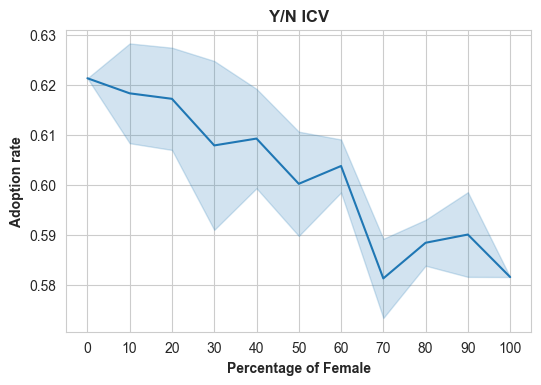

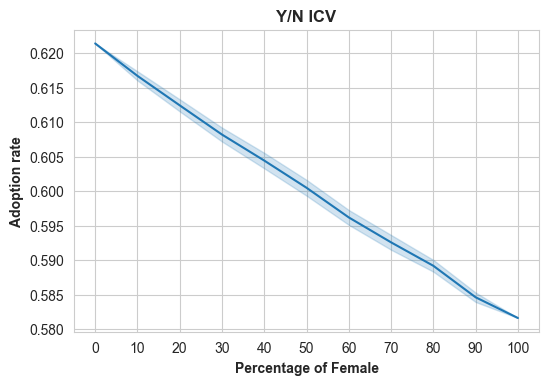

In [8]:
for y in experiment:
    for R in experiment[y]:
        fig1, ax1 = plt.subplots(dpi=100)
        tmp_data = experiment[y][R]
        
        # Only use bootrstrap 1
        sns.lineplot(ax=ax1, data=tmp_data[tmp_data['bootstrap'] ==  'Bootstrap #1'], x="variable", y="value", 
                     # hue="bootstrap", style="bootstrap",
                     markers=True, 
                     errorbar=("se", 2))
        # ax1.set_ylim(experiment[y].min().value, ax1.get_ylim()[1])
        ax1.set_title(y, fontweight='bold')
        ax1.set_xlabel('Percentage of Female', fontweight='bold')
        ax1.set_ylabel('Adoption rate' if y == 'Y/N ICV' else 'Intensity of adoption', fontweight='bold')
        # ax1.legend(title='Boostrap method')
        
        plt.savefig(f'../Output/Figures/AdopRate_{R}.png',dpi = 300)

In [9]:
#########################################################################
# Create pseudo-datasets with different percentage of Male/female answers
# input: Dataset and percentage of female answers
# output: pseudo-dataset with the ICV_HH_yn values and Adop_rate.
#########################################################################
def sudo_share(df_M, df_F, rate, variable):
    # print(df.shape)
    num_fe = int(df_F.shape[0]*rate)
    num_ma = int(df_M.shape[0]*(1-rate))
    df_sample_fe =  df_F.sample(num_fe)
    df_sample_ma = df_M.sample(num_ma)
    
    df_sample_i = np.concatenate((df_sample_fe[variable].values, df_sample_ma[variable].values))
    df_sample_i = pd.DataFrame(df_sample_i, columns=[variable])
    Adop_rate = df_sample_i.sum() / df_M.shape[0]
    return [df_sample_i, Adop_rate]

# Weighted selection: p_i is the probability of selecting element i
def weighted(p):
    y = rand.random()
    k=0
    while k<len(p) and y>=p[k]:
        y -= p[k]
        k+=1
    return k

df_FM_test = pd.read_csv("../Output/df_FM.csv")

p = (df_FM_test['ZoneID'].value_counts()/df_FM_test['ZoneID'].value_counts().sum()).sort_index().values


df_F_test = df_FM_test[df_FM_test['A02_Sex'] == 0].rename(columns=variables_dict)
df_M_test = df_FM_test[df_FM_test['A02_Sex'] == 1].rename(columns=variables_dict)
dep_self =  list(map(lambda x: variables_dict[x], dependent_self_reported))

experiment_zone = {y:{} for y in dep_self}


for y in dep_self[:1]: # if run for Y/N ICV and Total ICV
    experiment_zone[y] = {}
    for R in [5, 500]: # if run for for different n sizes 
        df_all_mc_results = []
        df_mc_results_cluster = {}
        for selected_cluster in df_FM_test['ZoneID'].unique():
            df_mc_results_cluster[selected_cluster] = []
            for i in range(R):
                df_sudo_cluster = []
                df_adop_rate_cluster = []
                for percentage in np.arange(0, 1.1, 0.1):
                    df_M_cluster = df_M_test[df_M_test['ZoneID'] == selected_cluster]
                    df_F_cluster = df_F_test[df_F_test['ZoneID'] == selected_cluster]
                    df_sample, adop_rate = sudo_share(df_M_cluster, df_F_cluster, round(percentage, 1), y)
                    df_sudo_cluster.append(df_sample)
                    df_adop_rate_cluster.append(adop_rate)


                df_sudo_cluster = pd.concat(df_sudo_cluster, axis=1, keys = ['0','10','20','30','40','50','60','70','80','90','100'])
                df_adop_rate_cluster = pd.concat(df_adop_rate_cluster, axis=1, keys=['0','10','20','30','40','50','60','70','80','90','100'])
                df_mc_results_cluster[selected_cluster].append(df_adop_rate_cluster)


            df_mc_results_cluster[selected_cluster] = pd.concat(df_mc_results_cluster[selected_cluster])
            df_mc_results_cluster[selected_cluster] = df_mc_results_cluster[selected_cluster].reset_index(drop=True)

            df_mc_cluster = df_mc_results_cluster[selected_cluster].melt()
            df_mc_cluster['ZoneID'] = selected_cluster
            
            df_all_mc_results.append(df_mc_cluster)
        
        df_mc_both = pd.concat(df_all_mc_results)
        # df_mc_both.columns = ['Percentage of Female', 'Adoption rate', 'Bootstrap method']
        experiment_zone[y][R] = df_mc_both
        

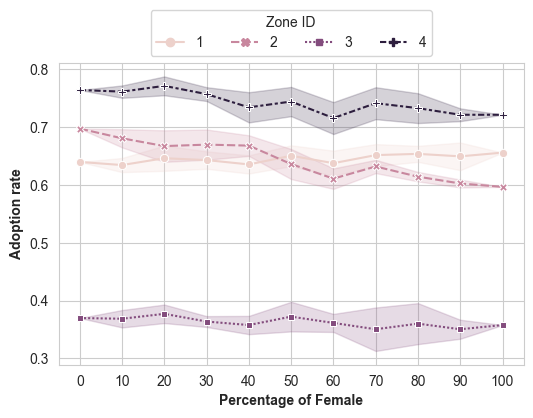

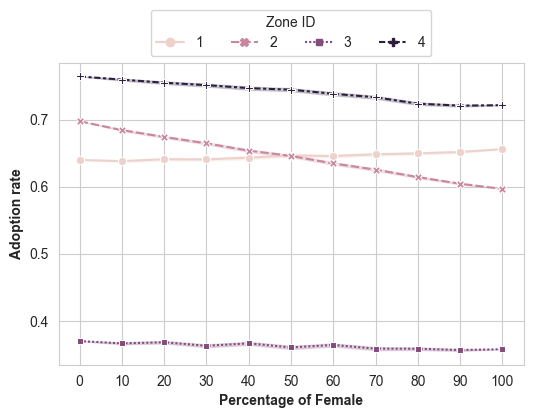

In [10]:
for y in experiment:
    for R in experiment[y]:
        fig1, ax1 = plt.subplots(dpi=100)
        tmp_data = experiment_zone[y][R]
        
        # Only use bootrstrap 1
        sns.lineplot(ax=ax1, data=tmp_data, x="variable", y="value", 
                     hue="ZoneID", style="ZoneID",
                     markers=True, 
                     errorbar=("se", 2))
        # ax1.set_ylim(experiment[y].min().value, ax1.get_ylim()[1])
        # ax1.set_title(y, fontweight='bold')
        ax1.set_xlabel('Percentage of Female', fontweight='bold')
        ax1.set_ylabel('Adoption rate' if y == 'Y/N ICV' else 'Intensity of adoption', fontweight='bold')
        ax1.legend(title='Zone ID', loc='lower center', bbox_to_anchor=(0.5, 1),
                  ncol=4)
        # ax1.legend(title='Boostrap method')
        
        plt.savefig(f'../Output/Figures/AdopRate_{R}_ByZone.png',dpi = 300)

# 2. Regressions
Run 4 regressions:  
- $Y_{husband} = X_{husband} \beta + C + \epsilon$
- $Y_{wife} = X_{wife} \beta + C + \epsilon$
- $Y_{DNA} = X_{husband} \beta + C + \epsilon$
- $Y_{DNA} = X_{wife} \beta + C + \epsilon$

In [11]:
dependent_self_reported = ['planted', 'Household_ICV']
dependent_DNA = ['DNA_planted', 'DNA_Household_ICV']

characteristic = ['ZoneID_1', 'ZoneID_3', 'ZoneID_4', # ZoneID_2 is base
                  'A03_Age', 'A05_Edu', 'Household_Size',
                  'A07_1_Main_occupatn_Farming', 'A07_1_Main_occupatn_Self_employed_off_farm', 
                  'A07_1_Main_occupatn_Other', # A07_1_Main_occupatn_Salaried_employment is base
                  'A08_fam_lab_contributn']

# J02_ percentage of household income comes from cassava? (%)
independent_income = ['J02_per_hh_inc_cassav']

independent_fertilized = ['J01_hhd_apply_fert']

independent_consumption = ['J05_consumption_perc']

# household member in coop group (0, 1)
independent_coop_member = ['Joint_Coop']

# general household credit access (0, 1)
independent_credit =  ['Credit_Access'] # Also check ['Joint_Credit']

# total household value of household assets
independent_household_asset = ['log_Total_Household_Asset_Value']

# total production asset value owned by house
independent_production_asset = ['log_Total_Production_Asset_Value']

# Cell_Owned
independent_Cell_Owned = ['Cell_Owned']

#Extension_Access
independent_Extension_Access = ['Extension_Access']

#independent = independent_coop_member + independent_credit  + independent_household_asset + independent_production_asset

independent = independent_coop_member + independent_credit  + independent_Extension_Access + independent_Cell_Owned + independent_fertilized + independent_consumption




In [12]:
df_FM_test = pd.read_csv("../Output/df_FM.csv")

df_F_test = df_FM_test[df_FM_test['A02_Sex'] == 0].rename(columns=variables_dict)
df_M_test = df_FM_test[df_FM_test['A02_Sex'] == 1].rename(columns=variables_dict)

ind = list(map(lambda x: variables_dict[x], independent))
char = list(map(lambda x: variables_dict[x], characteristic))
dep_self =  list(map(lambda x: variables_dict[x], dependent_self_reported))
dep_dna = list(map(lambda x: variables_dict[x], dependent_DNA))
zones = char[:3]


results = []

for y_self, y_DNA in zip(dep_self[:1], dep_dna[:1]):
    ##############################################
    # Self-reported regressions
    ##############################################
    # Husband 
    Y = df_M_test[y_self]
    X = sm.add_constant(df_M_test[ind + char], prepend=False)
    model_F = sm.Probit(Y,X) if y_self == 'Y/N ICV' else sm.OLS(Y,X)
    results_H_self = model_F.fit(cov_type='cluster', cov_kwds={'groups': df_M_test['ZoneID'].values}, maxiter=100, )
    results.append(results_H_self)
    
    # Wife 
    Y = df_F_test[y_self]
    X = sm.add_constant(df_F_test[ind + char], prepend=False)
    model_F = sm.Probit(Y,X) if y_self == 'Y/N ICV' else sm.OLS(Y,X)
    results_F_self = model_F.fit(cov_type='cluster', cov_kwds={'groups': df_F_test['ZoneID'].values}, maxiter=100, )
    results.append(results_F_self)

    ##############################################
    # DNA-fingerprint regressions
    ##############################################
    # Husband
    Y = df_M_test[y_DNA]
    X = sm.add_constant(df_M_test[ind + char], prepend=False)
    model_M = sm.Probit(Y,X) if y_DNA == 'DNA Y/N ICV' else sm.OLS(Y,X)
    results_H_DNA = model_M.fit(cov_type='cluster', cov_kwds={'groups': df_M_test['ZoneID'].values}, maxiter=100, )
    results.append(results_H_DNA)
    
    # Wife 
    Y = df_F_test[y_DNA]
    X = sm.add_constant(df_F_test[ind + char], prepend=False)
    model_F = sm.Probit(Y,X) if y_DNA == 'DNA Y/N ICV' else sm.OLS(Y,X)
    results_F = model_F.fit(cov_type='cluster', cov_kwds={'groups': df_F_test['ZoneID'].values}, maxiter=100, )
    results.append(results_F)


columns_dataset_level_1 = {0: 'Y/N ICV', 1: "Total ICV"}

columns_dataset_level_2 = {0: 'Husband', 1: 'Husband', 2: 'Wife', 3: 'Wife', 
                           4: 'Husband', 5: 'Husband', 6: 'Wife', 7: 'Wife'}

columns_dataset_level_3 = {0: 'Self-reported', 1: "DNA"}

summary_str  = summary_col(results, 
                  stars=True,
                  model_names=[#columns_dataset_level_1[i//4] + "-" +  
                                columns_dataset_level_2[i] + "-" + 
                               columns_dataset_level_3[i%2] for i in range(len(results))],
                  float_format='%.3f',
                  info_dict={
                      'N':lambda x: "{0:d}".format(int(x.nobs))
                  },
                  regressor_order=ind + char
                          )# .as_latex()

df_results = summary_str.tables[0]
# df_results.columns = ['DNA' if i%2==0 else 'Self-reported' for i in range(df_results.columns.shape[0])]
df_results.to_latex("../Output/Tables/tab_regressions.tex", escape=False)
df_results


Optimization terminated successfully.
         Current function value: 0.593901
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.633044
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.619256
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.614573
         Iterations 5


,Husband-Self-reported,Husband-DNA,Wife-Self-reported,Wife-DNA
Joint Coop,0.118**,0.013,0.095,-0.044
,(0.059),(0.168),(0.091),(0.061)
Household Credit,-0.059,-0.035,-0.009,0.096
,(0.067),(0.125),(0.110),(0.159)
Extension Access,0.453***,0.214**,0.099,-0.111
,(0.066),(0.100),(0.117),(0.138)
Cellphone,0.267,-0.058,0.039,-0.038
,(0.449),(0.344),(0.203),(0.444)
Fertilizer,0.092***,0.246*,-0.124,0.106
,(0.029),(0.136),(0.116),(0.170)


['__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_check_kwargs',
 '_data_attr',
 '_df_model',
 '_df_resid',
 '_fit_collinear',
 '_fit_ridge',
 '_fit_zeros',
 '_formula_max_endog',
 '_get_init_kwds',
 '_handle_data',
 '_init_keys',
 '_kwargs_allowed',
 '_setup_score_hess',
 '_sqrt_lasso',
 'data',
 'df_model',
 'df_resid',
 'endog',
 'endog_names',
 'exog',
 'exog_names',
 'fit',
 'fit_regularized',
 'from_formula',
 'get_distribution',
 'hessian',
 'hessian_factor',
 'information',
 'initialize',
 'k_constant',
 'loglike',
 'nobs',
 'pinv_wexog',
 'predict',
 'rank',
 'score',
 'weights',
 'wendog',
 'wexog',
 'whiten']

In [ ]:
df_F_test = df_FM_test[df_FM_test['A02_Sex'] == 0].rename(columns=variables_dict)
df_M_test = df_FM_test[df_FM_test['A02_Sex'] == 1].rename(columns=variables_dict)

for i in ind + char:
    print(df_F_test[i].isna().unique())

# 3. Oaxaca-blinder decomposition

In [19]:
dependent_self_reported = ['planted', 'Household_ICV']
dependent_DNA = ['DNA_planted', 'DNA_Household_ICV']

characteristic = ['ZoneID_1', 'ZoneID_3', 'ZoneID_4', # ZoneID_2 is base
                  'A03_Age', 'A05_Edu', 'Household_Size',
                  'A07_1_Main_occupatn_Farming', 'A07_1_Main_occupatn_Self_employed_off_farm', 
                  'A07_1_Main_occupatn_Other', # A07_1_Main_occupatn_Salaried_employment is base
                  'A08_fam_lab_contributn']

# J02_ percentage of household income comes from cassava? (%)
independent_income = ['J02_per_hh_inc_cassav']

independent_fertilized = ['J01_hhd_apply_fert']

independent_consumption = ['J05_consumption_perc']

# household member in coop group (0, 1)
independent_coop_member = ['Coop_self']

# general household credit access (0, 1)
#independent_credit =  ['Credit_self'] # Also check ['Joint_Credit']

# total household value of household assets
independent_household_asset = ['log_Total_Household_Asset_Value']

# total production asset value owned by house
independent_production_asset = ['log_Total_Production_Asset_Value']

# Cell_Owned
independent_Cell_Owned = ['Cell_Own_self']

#Extension_Access
independent_Extension_Access = ['Extension_Access_self']

#independent = independent_coop_member + independent_credit  + independent_household_asset + independent_production_asset

independent = independent_coop_member + independent_credit  + independent_Extension_Access + independent_Cell_Owned + independent_fertilized + independent_consumption
#independent = independent_coop_member  + independent_Extension_Access + independent_Cell_Owned + independent_fertilized + independent_consumption



In [ ]:
df_FM_test = pd.read_csv("../Output/df_FM.csv")

df_F_test = df_FM_test[df_FM_test['A02_Sex'] == 0]#.rename(columns=variables_dict)
df_M_test = df_FM_test[df_FM_test['A02_Sex'] == 1]#.rename(columns=variables_dict)

for i in independent + characteristic:
    print(df_F_test[i].isna().unique())

## 3.1 Gender gap between self-reported  values

In [23]:
df_results = []

## Select the group A and B
groupA = 'F' # Female
groupB = 'M' # Male
dataset = f'{groupA}{groupB}'

for y in ['ICV_Managed_self']:
    group = 'A02_Sex'
    formula = f'{y} ~ ' + ' + '.join(independent) + " + " + ' + '.join(characteristic[3:]) + f' | {group} ' + \
                ' | ' + ' + '.join(characteristic[:3])
    #formula = f'{dependent} ~ ' + ' + '.join(independent)  +  f' | {group}' 
    print(formula)
    extra = 'reg.fun = glm, family = binomial(link = "probit")' if y == 'planted' else ''
    
    # print(formula)
    robjects.r(f''' 
        df <- read.csv("../Output/df_{dataset}.csv")
        results <- oaxaca(formula = {formula}, data=df, {extra}, R=10)

    ''')


    results = robjects.globalenv['results']
    resulst_dict = dict(zip(results.names, results))
    resulst_dict_threefold = dict(zip(resulst_dict['threefold'].names, 
                                      list(resulst_dict['threefold'])))
    
    results_dict_y =dict(zip(resulst_dict['y'].names, resulst_dict['y']))
    # print(resulst_dict_threefold['variables'])
    #print(y, '\t'
    #      'Group A = ', '{:.3f}'.format(results_dict_y['y.A'][0]), 
    #      ', Group B = ',   '{:.3f}'.format(results_dict_y['y.B'][0]), 
    #      ', Mean gender gap=', '{:.3f}'.format(results_dict_y['y.diff'][0])) 
    
    df_tmp = update_results(resulst_dict_threefold, independent, characteristic, base =['(Base)'], 
                            variables_dict=variables_dict)
    df_tmp.columns = pd.MultiIndex.from_product([[y], df_tmp.columns])
    
    df_si_level = df_tmp.copy()
    df_si_level.columns = df_si_level.columns.droplevel(1)

    df_new = pd.DataFrame(np.zeros((3, 3)), columns=df_si_level.columns, index = ['Wives', 'Husbands', 'Mean gender gap'])
    df_new = df_new.replace(0, "")
    df_new.iat[0, 0] = '{:.3f}'.format(results_dict_y['y.A'][0])
    df_new.iat[1,0] = '{:.3f}'.format(results_dict_y['y.B'][0])
    df_new.iat[2,0] = '{:.3f}'.format(results_dict_y['y.diff'][0])
    df_new.loc[''] = df_tmp.columns.get_level_values(1)

    df_results.append(pd.concat([df_new, df_si_level]))

df_results = pd.concat(df_results, axis=1)
df_results.to_latex("../Output/Tables/tab_oaxaca_FM.tex", escape=False)
df_results

ICV_Managed_self ~ Coop_self + Credit_Access + Extension_Access_self + Cell_Own_self + J01_hhd_apply_fert + J05_consumption_perc + A03_Age + A05_Edu + Household_Size + A07_1_Main_occupatn_Farming + A07_1_Main_occupatn_Self_employed_off_farm + A07_1_Main_occupatn_Other + A08_fam_lab_contributn | A02_Sex  | ZoneID_1 + ZoneID_3 + ZoneID_4


TypeError: 'NULLType' object is not iterable